<img src="https://raw.githubusercontent.com/2248220hub/OpenCarbon-Forest-FireDebt-EO-Toolkit/main/assets/banner.png" width="100%" alt="OpenCarbon Forest Fire-Debt EO Toolkit">

# OpenCarbon · Forest Fire-Debt EO Toolkit

**How much carbon, methane and biomass did a forest fire release — and how long will the forest take to pay it back?**

This notebook answers that from free satellite data, end to end, inside Google Earth Engine. Everything site-specific lives in **one configuration cell**, so you can point it at another Mediterranean forest fire without touching the science. The worked example is the **Arischia fire** (L'Aquila, Italy, 30 Jul – 13 Aug 2020), and its results are saved in the notebook so you can see what each block should produce before you run it.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/2248220hub/OpenCarbon-Forest-FireDebt-EO-Toolkit/blob/main/notebooks/OpenCarbon_FireDebt_Toolkit.ipynb) &nbsp; [![Repository](https://img.shields.io/badge/GitHub-repository-181717?logo=github)](https://github.com/2248220hub/OpenCarbon-Forest-FireDebt-EO-Toolkit) &nbsp; ![Licence: MIT](https://img.shields.io/badge/licence-MIT-green)

**Vinoth Emberumal** · MSc Space & Astronautical Engineering, Sapienza University of Rome · Earth Observation course, Prof. Ferdinando Nunziata

### The pipeline at a glance

| Block | Question it answers | Data | Domain | Main output |
|:--:|---|---|---|---|
| **0** | Setup | — | — | configuration, results register |
| **1** | What *could* burn? | CORINE 2018 · WorldCover 2020 · Copernicus EMS | land cover | fuel map, ha per forest class |
| **2** | What state was the forest in? | ESA CCI Biomass · Sentinel-2 · ERA5-Land | optical · reanalysis | standing biomass, pre-fire dryness |
| **3** | What burned, and how badly? | Sentinel-2 MSI | **optical** | dNBR, RBR, four severity classes |
| **4** | How much energy did it radiate? | MODIS Terra + Aqua | **thermal** | FRP, FRE, diurnal duty cycle |
| **5A** | How much gas? | emission-factor table | budget | CO₂, CO, CH₄, PM₂.₅ + Monte-Carlo range |
| **5B** | Does severity change that? | interactive β sliders | budget | β-by-severity budget |
| **6A** | Could a satellite see the methane? | Sentinel-5P TROPOMI | **atmospheric chemistry** | pre-registered prediction, then the test |
| **6B** | For any plume shape? | forward model | detectability | detection floor over 27 geometries |
| **7A** | Is the forest coming back? | Sentinel-2, 11 summers | optical time series | NBR per severity class + unburnt control |
| **7B** | When will it finish? | exponential recovery model | **prediction** | canopy-recovery years, methane-sink window |
| **8** | Show it | folium · matplotlib | dashboard | interactive map, register, summary figure |

### How to read this notebook
Every block opens with the same short card — **why** it exists, the **key formula**, the **terms** you need, what to **change** for your own fire, and the **Arischia result** to compare against. Code is left visible on purpose: read it, change it, break it. Each number the code computes is written into one results register (`R`) and exported to CSV at the end, so nothing in the write-up comes from memory.

---
## Before you start · 10-minute setup

You need nothing installed on your computer. Everything runs in the browser.

| # | Step | Where | Time |
|:--:|---|---|:--:|
| 1 | A Google account | — | — |
| 2 | Register for **Earth Engine** (free for research, education and non-profit use) and create or pick a **Google Cloud project** | [code.earthengine.google.com/register](https://code.earthengine.google.com/register) | 5 min |
| 3 | Make sure the **Earth Engine API** is enabled on that project, and copy its **project ID** (looks like `my-project-123456`) | [console.cloud.google.com](https://console.cloud.google.com/) | 2 min |
| 4 | Open this notebook in Colab — the badge at the top, or *File → Open notebook → GitHub* | [colab.research.google.com](https://colab.research.google.com/) | — |
| 5 | In **Block 0**, paste your project ID into `GEE_PROJECT` in the form | this notebook | 1 min |
| 6 | *Runtime → Run all*. Accept the two pop-ups: Earth Engine sign-in, then Google Drive | this notebook | — |

**Where results go.** Block 0 mounts your Google Drive and creates `MyDrive/<DRIVE_DIR>/` with `data/`, `figures/` and `docs/`. Tables are saved as CSV, figures as PNG, dashboards as HTML — open the HTML files in any browser.

**Run order matters.** Blocks build on each other (Block 5 needs the fuel map and severity map from Blocks 1–3). Run top to bottom. A full run takes roughly 10–20 minutes, almost all of it waiting on Earth Engine.

**If something fails**

| Message | What it means | Fix |
|---|---|---|
| `EEException: … project … not registered` / `not found` | the Cloud project isn't registered for Earth Engine | finish step 2–3, then re-run Block 0 |
| `Please set GEE_PROJECT` | you left the placeholder in the form | paste your own project ID |
| `Collection asset … not found` | a geometry or asset ID is wrong | check `AOI_BBOX`, `EMS_*` and `AGB_YEAR` in Block 0 |
| `Computation timed out` | the request is too large for an interactive call | shrink `AOI_BBOX` to the fire plus ~1 km margin |
| `HTTP Error 404` in Block 1 | the EMS file name doesn't exist | copy the exact `…_vector.zip` name from the EMS portal (see Block 1), or leave `EMS_ZIP` empty |
| Map layers blank on GitHub | GitHub cannot run the Earth Engine tile server | run the notebook in Colab, or open the saved HTML dashboard |

---
## Block 0 · Configuration — the only cell you have to edit
**Why.** Every site-specific choice is gathered here so the rest of the notebook stays the same for any fire. In Colab the `# @param` lines appear as a form on the right; you can also edit the values directly.

| Parameter | What it controls | Arischia value | How to choose yours |
|---|---|---|---|
| `GEE_PROJECT` | your Earth Engine Cloud project | *(personal)* | from the setup steps above |
| `DRIVE_DIR` | output folder in your Google Drive | `OpenCarbon-FireDebt` | anything |
| `SITE`, `SITE_LABEL` | names printed on tables and dashboards | Arischia | free text |
| `AOI_BBOX` | study box `[west, south, east, north]` in degrees | 13.24, 42.34, 13.44, 42.50 | fire perimeter + ~1–2 km |
| `CTRL_BBOX` | **unburnt control** forest of the same type, nearby | 13.55, 42.34, 13.75, 42.50 | same forest type and elevation, **no fire detections** in the period |
| `PRE`, `POST` | dates of the clearest Sentinel-2 scenes just before and after | 2020-07-29, 2020-08-13 | pick cloud-free overpasses (±3 days are composited) |
| `FIRE_START`, `FIRE_END` | burning period; **end is exclusive** (day after the fire ended) | 2020-07-30, 2020-08-14 | from EMS, EFFIS or FIRMS |
| `EMS_ACTIVATION`, `EMS_ZIP`, `EMS_LAYER` | reference perimeter from Copernicus EMS | EMSR449 · DEL_MONIT03 · observedEventA | see Block 1; leave `EMS_ZIP` empty if there is no activation |
| `AGB_YEAR` | ESA CCI biomass map year (the last one *before* the fire) | 2019 | check the years available in the Earth Engine catalogue |
| `MOISTURE_WINDOW` | month-days used for the pre-fire dryness test | 07-01 → 07-28 | the weeks just before ignition |
| `LAST_YEAR` | last summer in the recovery series | 2026 | the latest complete summer |
| `BURN_MIN` | dNBR above which a pixel counts as burned | 0.16 | 0.10–0.20; calibrate against the EMS perimeter |
| `SEV_BREAKS` | dNBR edges between Low / Moderate / High / Very high | 0.27, 0.44, 0.66 | Key & Benson (2006) defaults |
| `REF_CH4` | an external published CH₄ value, used **only** for comparison | 59.60 t | a paper for your fire, or `0` |

**The results register.** `rec(block, name, value, unit)` prints a line like `[5] CH4 emitted  65.07 t` and stores it in `R`. Block 8 exports `R` to `data/outputs/session1_results.csv`. `rec_model()` does the same but tags the value **[MODELLED]** — used for anything that is inferred rather than observed.

In [2]:
# @title Block 0 · Configuration — fill in the form, then run
# Everything site-specific lives in this cell. Change these values to analyse
# another forest fire; every later block reads them.
!pip install -q earthengine-api geopandas folium

import ee, os, json, glob, zipfile, urllib.request
import pandas as pd, numpy as np, folium, geopandas as gpd
import matplotlib.pyplot as plt

# ── 1 · Accounts ───────────────────────────────────────────────────────────
GEE_PROJECT = 'concise-bloom-506717-m0'                       # @param {type:"string"}
DRIVE_DIR   = 'OpenCarbon-FireDebt'                       # @param {type:"string"}

# ── 2 · Where and when ─────────────────────────────────────────────────────
SITE        = 'Arischia'                                  # @param {type:"string"}
SITE_LABEL  = "Arischia forest fire · L'Aquila, Abruzzo"  # @param {type:"string"}
AOI_BBOX    = [13.24, 42.34, 13.44, 42.50]                # @param {type:"raw"}
CTRL_BBOX   = [13.55, 42.34, 13.75, 42.50]                # @param {type:"raw"}
PRE         = '2020-07-29'                                # @param {type:"date"}
POST        = '2020-08-13'                                # @param {type:"date"}
FIRE_START  = '2020-07-30'                                # @param {type:"date"}
FIRE_END    = '2020-08-14'                                # @param {type:"date"}

# ── 3 · Reference perimeter (Copernicus EMS) — leave EMS_ZIP empty if none ──
EMS_ACTIVATION = 'EMSR449'                                # @param {type:"string"}
EMS_ZIP     = 'EMSR449_AOI01_DEL_MONIT03_r1_RTP01_v1_vector.zip'  # @param {type:"string"}
EMS_LAYER   = 'MONIT03_observedEventA'                    # @param {type:"string"}

# ── 4 · Data years and windows ─────────────────────────────────────────────
AGB_YEAR        = 2019                                    # @param {type:"integer"}
MOISTURE_WINDOW = ('07-01', '07-28')                      # @param {type:"raw"}
LAST_YEAR       = 2026                                    # @param {type:"integer"}

# ── 5 · Science knobs ──────────────────────────────────────────────────────
BURN_MIN    = 0.16                                        # @param {type:"number"}
SEV_BREAKS  = [0.27, 0.44, 0.66]                          # @param {type:"raw"}
REF_CH4     = 59.60                                       # @param {type:"number"}

# ── 6 · Labels for the dashboard ───────────────────────────────────────────
DASHBOARD_TITLE = ('Satellite Quantification Of The Methane Budget And Post-Fire '
                   'Recovery Prediction-Model Of A Mediterranean Forest Fire')
AUTHOR_LINE     = ('V. Emberumal &middot; MSc Space &amp; Astronautical Eng., '
                   'Sapienza &middot; Earth Observation')

# ── connect ────────────────────────────────────────────────────────────────
assert GEE_PROJECT != 'your-gee-project-id', 'Please set GEE_PROJECT to your own Earth Engine Cloud project ID.'
ee.Authenticate()
ee.Initialize(project=GEE_PROJECT)

from google.colab import drive; drive.mount('/content/drive')
PROJ = f'/content/drive/MyDrive/{DRIVE_DIR}'
for s in ['data/reference', 'data/outputs', 'figures', 'docs']:
    os.makedirs(f'{PROJ}/{s}', exist_ok=True)

# ── derived geometry and dates ─────────────────────────────────────────────
AOI       = ee.Geometry.Rectangle(AOI_BBOX)
CONTROL   = ee.Geometry.Rectangle(CTRL_BBOX)
REGION    = AOI.union(CONTROL, 1)
FIRE      = (FIRE_START, FIRE_END)
FIRE_YEAR = int(FIRE_START[:4])

# ── results register: every number the notebook computes lands here ────────
R = {}
def rec(b, k, v, u=''):
    R[k] = {'block': b, 'value': v, 'unit': u}
    s = f'{v:,.2f}' if isinstance(v, (int, float)) else str(v)
    print(f'  [{b}] {k:<34}{s:>14}  {u}')

def rec_model(b, k, v, u=''):
    """Same as rec(), but tags the value as MODELLED (inferred, not observed)."""
    return rec(b, '[MODELLED] ' + k, v, u)

MODEL_NOTE = ('MODELLED — derived from a literature rate scaled by an observed '
              'proxy, not measured. Validation would require flux chambers or '
              'an eddy-covariance tower.')

# ── small Earth Engine helpers ─────────────────────────────────────────────
PX_HA = ee.Image.pixelArea().divide(1e4)
def ha(mask, geom, scale=20):
    """Area in hectares of a mask inside a geometry."""
    img = PX_HA if mask is None else PX_HA.updateMask(mask)
    v = img.reduceRegion(reducer=ee.Reducer.sum(), geometry=geom, scale=scale, maxPixels=1e10).getInfo()
    return float(v.get('area') or 0)

def zs(img, mask, geom, red, scale=100):
    """Zonal statistic (mean, stdDev, ...) of an image inside a masked geometry."""
    v = img.updateMask(mask).reduceRegion(reducer=red, geometry=geom, scale=scale, maxPixels=1e10).getInfo()
    return float(list(v.values())[0] or 0)

def ee_tile(img, vis, name, show=False):
    """An Earth Engine image as a folium tile layer."""
    return folium.raster_layers.TileLayer(
        tiles=ee.Image(img).getMapId(vis)['tile_fetcher'].url_format, attr='GEE',
        name=name, overlay=True, control=True, show=show, max_zoom=20)

print('Earth Engine connected')
print(f'Configuration loaded for {SITE}: fire {FIRE_START} to {FIRE_END}, outputs in {PROJ}')

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Mounted at /content/drive
Earth Engine connected
Configuration loaded for Arischia: fire 2020-07-30 to 2020-08-14, outputs in /content/drive/MyDrive/OpenCarbon-FireDebt


---
## Block 1 · Fuel map — what could burn?
**Why.** A fire perimeter drawn by analysts contains roads, meadows, bare rock and villages. Counting those as forest inflates every number downstream, so we first keep only land that is *both* classified as forest and actually covered by trees or shrubs.

**Key formula** &nbsp; `FUEL = CORINE ∈ {311, 312, 313, 324}  ∩  WorldCover ∈ {10 tree, 20 shrub}`

**Terms**
- **CORINE Land Cover 2018** — EU land-cover map, 100 m, 44 classes, satellite imagery interpreted by experts. Gives the fuel **type**.
- **ESA WorldCover 2020** — global 10 m map classified automatically from Sentinel-1 + Sentinel-2. Gives the fuel **extent**.
- **Copernicus EMS** — the EU Emergency Management Service; its *rapid-mapping* products are burn perimeters drawn during the event. We use it as independent reference geometry.
- **Slope** — from the Copernicus GLO-30 DEM; steep terrain matters later for radar and for fire behaviour.

**Change for your fire**
- Find your activation on the [Copernicus EMS rapid-mapping portal](https://rapidmapping.emergency.copernicus.eu/). Open the latest *delineation* (DEL) or *monitoring* (MONIT) product, copy the vector package name (`…_vector.zip`) into `EMS_ZIP`, and set `EMS_LAYER` to the burnt-area layer (`observedEventA`).
- No activation? Leave `EMS_ZIP = ''` — the AOI box becomes the reference geometry.
- Different forest types? Edit `CODES` / `NAMES`. For maquis, add CORINE **323** (sclerophyllous vegetation) — and add a matching row to the emission-factor table in Block 5A.

**Arischia result** &nbsp; 638.99 ha EMS perimeter → **458.0 ha** of real fuel (28.3 % removed) · coniferous 60 % · mean slope 23°

In [3]:
# @title Block 1 · Fuel map — what could burn? {"vertical-output":true}
# ── reference perimeter: the Copernicus EMS vector, or the AOI box if there is none
if EMS_ACTIVATION and EMS_ZIP:
    EMS_BASE = f'https://cems-mapping-website.s3.eu-west-1.amazonaws.com/static/activations/{EMS_ACTIVATION}/'
    dst      = f'{PROJ}/data/reference'
    pattern  = f'{dst}/{EMS_ACTIVATION}/**/*{EMS_LAYER}*.shp'
    if not glob.glob(pattern, recursive=True):
        urllib.request.urlretrieve(EMS_BASE + EMS_ZIP, f'{dst}/{EMS_ZIP}')
        zipfile.ZipFile(f'{dst}/{EMS_ZIP}').extractall(f'{dst}/{EMS_ACTIVATION}')
    gdf = gpd.read_file(glob.glob(pattern, recursive=True)[0]).to_crs(4326)
else:
    from shapely.geometry import shape
    gdf = gpd.GeoDataFrame(geometry=[shape(AOI.getInfo())], crs=4326)
    print('  No EMS perimeter configured - using the AOI rectangle as the reference geometry.')
EMS_G = ee.FeatureCollection(json.loads(gdf.to_json())).geometry()

# ── fuel = forest class (CORINE, type) AND tree/shrub cover (WorldCover, extent)

CLC   = ee.Image('COPERNICUS/CORINE/V20/100m/2018').select('landcover').clip(REGION)
WC    = ee.ImageCollection('ESA/WorldCover/v100').first().select('Map').clip(REGION)
TREES = WC.eq(10).Or(WC.eq(20))                        # 10 m, 2020 epoch
CODES = [311, 312, 313, 324]                           # CORINE classes counted as fuel
NAMES = {311:'Broad-leaved', 312:'Coniferous', 313:'Mixed', 324:'Woodland-shrub'}
FUEL  = CLC.remap(CODES, [1]*4, 0).And(TREES).selfMask()

B1 = pd.DataFrame([{'clc':c, 'class':NAMES[c],
                    'ha': round(ha(CLC.eq(c).And(TREES).selfMask(), EMS_G),1)} for c in CODES])
B1['%'] = (100*B1.ha/B1.ha.sum()).round(1); display(B1)
rec(1,'Reference perimeter', gdf.to_crs(3035).area.sum()/1e4,'ha')
rec(1,'Fuel area (10 m mask)', B1.ha.sum(),'ha')
rec(1,'Mean slope', zs(ee.Terrain.slope(ee.ImageCollection('COPERNICUS/DEM/GLO30_2024_1')
        .select('DEM').mosaic().setDefaultProjection('EPSG:3857',None,30)), FUEL, EMS_G,
        ee.Reducer.mean(), 30),'deg')

,clc,class,ha,%
0,311,Broad-leaved,43.8,9.6
1,312,Coniferous,275.1,60.1
2,313,Mixed,53.4,11.7
3,324,Woodland-shrub,85.7,18.7


  [1] Reference perimeter                       638.99  ha
  [1] Fuel area (10 m mask)                     458.00  ha
  [1] Mean slope                                 23.06  deg


---
## Block 2 · Pre-fire state — how much biomass, and was it dry?
**Why.** Emissions scale with how much biomass was standing. And if the forest was already drought-stressed, that is a cause worth separating from the fire itself.

**Key formulas**
- `NDMI = (B8 − B11) / (B8 + B11)` — normalised difference moisture index (near-infrared vs short-wave infrared, which water absorbs)
- `anomaly σ = (NDMI_fire-year − mean(NDMI_baseline)) / sd(NDMI_baseline)`, same calendar window every year so the seasonal cycle cancels

**Terms**
- **AGB** — above-ground biomass, t ha⁻¹, from ESA CCI Biomass v6 (100 m). We take the mean and standard deviation per fuel class; the standard deviation feeds the Monte Carlo in Block 5A.
- **SCL** — Sentinel-2's scene-classification layer. Classes 3, 8, 9, 10, 11 (cloud shadow, cloud medium/high, cirrus, snow) are masked everywhere in this notebook.
- **ERA5-Land** — ECMWF reanalysis, ~9 km. Temperature and total precipitation from 1 June to ignition.

**Change for your fire** &nbsp; `AGB_YEAR`, `MOISTURE_WINDOW` (Block 0).

**Arischia result** &nbsp; 117.3 t ha⁻¹ mean · **53,694 t** standing on 458 ha · NDMI anomaly **−0.66 σ** (drier, but *not* anomalously so) · 180.6 mm rain and 18.1 °C in the weeks before · baseline years 2016, 2018, 2019 (2017 had no clear scene)

In [4]:
# @title Block 2 · Pre-fire state — biomass, dryness, weather {"vertical-output":true}
AGB = ee.Image(f'ESA/CCI/Above_Ground_Biomass/V6_0/{AGB_YEAR}').select('agb')
S2C = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')

# ---- standing biomass per fuel class (mean and spread feed the Monte Carlo) ---
B2 = B1.copy()
B2['agb_t_ha'] = [round(zs(AGB, CLC.eq(c).And(TREES).selfMask(), EMS_G, ee.Reducer.mean()),1)   for c in CODES]
B2['agb_sd']   = [round(zs(AGB, CLC.eq(c).And(TREES).selfMask(), EMS_G, ee.Reducer.stdDev()),1) for c in CODES]
B2['stock_t']  = (B2.ha*B2.agb_t_ha).round(0); display(B2)
rec(2,'Mean AGB density', zs(AGB, FUEL, EMS_G, ee.Reducer.mean()),'t/ha')
rec(2,'Standing biomass', B2.stock_t.sum(),'t')

# ---- same-season moisture anomaly ------------------------------------------
# The fire-year window is compared with the same window in the four previous
# years, so canopy phenology is identical in every sample and only moisture remains.
def july_ndmi(year):
    c = (S2C.filterBounds(AOI).filterDate(f'{year}-{MOISTURE_WINDOW[0]}', f'{year}-{MOISTURE_WINDOW[1]}')   # pre-ignition
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
           .map(lambda i: i.updateMask(i.select('SCL').remap([3,8,9,10,11],[0]*5,1))))
    try:    return round(zs(c.median().normalizedDifference(['B8','B11']), FUEL, EMS_G, ee.Reducer.mean(), 20), 4)
    except: return np.nan

NDMI = pd.DataFrame({'year': list(range(FIRE_YEAR - 4, FIRE_YEAR + 1))})
NDMI['july_NDMI'] = [july_ndmi(y) for y in NDMI.year]
base = NDMI[NDMI.year < FIRE_YEAR].july_NDMI.dropna()
NDMI['anomaly'] = (NDMI.july_NDMI - base.mean()).round(4)
NDMI['sigma']   = (NDMI.anomaly / base.std()).round(2)
display(NDMI)

a20 = float(NDMI.loc[NDMI.year == FIRE_YEAR, 'anomaly'].iloc[0])
s20 = float(NDMI.loc[NDMI.year == FIRE_YEAR, 'sigma'].iloc[0])
rec(2,f'July NDMI baseline {FIRE_YEAR-4}-{FIRE_YEAR-1}', base.mean(),'')
rec(2,f'July {FIRE_YEAR} NDMI anomaly',       a20,'')
rec(2,'Anomaly in baseline sigma',    s20,'sigma')
print(f"\n  Interpretation: {'drier' if a20 < 0 else 'wetter'} than the four-year July mean "
      f"by {abs(s20):.2f} sigma. |sigma| < 1 means the canopy was NOT anomalously dry.")

# ---- weather from 1 June to ignition (ERA5-Land) ---------------------------
era = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR').filterDate(f'{FIRE_YEAR}-06-01', FIRE_START)
rec(2,'Mean 2m T Jun-Jul',  zs(era.select('temperature_2m').mean().subtract(273.15), FUEL, EMS_G, ee.Reducer.mean(), 1000),'degC')
rec(2,'Precip Jun-Jul',     zs(era.select('total_precipitation_sum').sum().multiply(1000), FUEL, EMS_G, ee.Reducer.mean(), 1000),'mm')

,clc,class,ha,%,agb_t_ha,agb_sd,stock_t
0,311,Broad-leaved,43.8,9.6,112.0,29.3,4906.0
1,312,Coniferous,275.1,60.1,125.7,17.2,34580.0
2,313,Mixed,53.4,11.7,112.8,27.2,6024.0
3,324,Woodland-shrub,85.7,18.7,95.5,36.6,8184.0


  [2] Mean AGB density                          117.35  t/ha
  [2] Standing biomass                       53,694.00  t


,year,july_NDMI,anomaly,sigma
0,2016,NaN,NaN,NaN
1,2017,0.2856,-0.0160,-1.15
2,2018,0.3077,0.0061,0.44
3,2019,0.3114,0.0098,0.70
4,2020,0.2924,-0.0092,-0.66


  [2] July NDMI baseline 2016-2019                0.30  
  [2] July 2020 NDMI anomaly                     -0.01  
  [2] Anomaly in baseline sigma                  -0.66  sigma

  Interpretation: drier than the four-year July mean by 0.66 sigma. |sigma| < 1 means the canopy was NOT anomalously dry.
  [2] Mean 2m T Jun-Jul                          18.07  degC
  [2] Precip Jun-Jul                            180.63  mm


---
## Block 3 · The fire — what burned, and how badly?
**Why.** Burned area and burn severity are the two numbers everything else rests on. Severity matters because a lightly scorched stand loses a fraction of its fuel; a crown fire loses most of it.

**Key formulas**
- `NBR = (B8 − B12) / (B8 + B12)` — normalised burn ratio: healthy leaves are bright at 842 nm (B8), char and dry soil are bright at 2190 nm (B12)
- `dNBR = NBR_pre − NBR_post`
- `RBR = dNBR / (NBR_pre + 1.001)` — relativised burn ratio (Parks 2014), removes the dependence on how green the stand was
- burned if `dNBR ≥ BURN_MIN`; classes Low / Moderate / High / Very high at `SEV_BREAKS` (Key & Benson 2006)

**Terms** &nbsp; **median composite** — the per-pixel median of every clear scene within ±3 days of `PRE` / `POST`, cloud cover < 40 %.

**Change for your fire** &nbsp; `PRE`, `POST`, `BURN_MIN`, `SEV_BREAKS`.

**Arischia result** &nbsp; **309.0 ha** of forest burned · Low 95.7 · Moderate 79.1 · High 52.3 · Very high 81.9 ha · mean dNBR 0.48

In [5]:
# @title Block 3 · Burned area and burn severity (Sentinel-2)
def scene(date, days=3):
    d = ee.Date(date)
    return (S2C.filterBounds(REGION).filterDate(d.advance(-days,'day'), d.advance(days+1,'day'))
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE',40))
              .map(lambda i: i.updateMask(i.select('SCL').remap([3,8,9,10,11],[0]*5,1))))

PRE_I, POST_I = scene(PRE).median().clip(REGION), scene(POST).median().clip(REGION)
NBRp = PRE_I.normalizedDifference(['B8','B12'])
dNBR = NBRp.subtract(POST_I.normalizedDifference(['B8','B12'])).rename('dNBR')
RBR  = dNBR.divide(NBRp.add(1.001)).rename('RBR')
BURN = dNBR.gte(BURN_MIN).And(FUEL)
b1, b2, b3 = SEV_BREAKS                                  # Low | Moderate | High | Very high
SEV  = (ee.Image(0).where(dNBR.gte(BURN_MIN).And(dNBR.lt(b1)),1)
                   .where(dNBR.gte(b1).And(dNBR.lt(b2)),2)
                   .where(dNBR.gte(b2).And(dNBR.lt(b3)),3)
                   .where(dNBR.gte(b3),4).updateMask(FUEL).rename('sev'))

CLASSES = {1:'Low', 2:'Moderate', 3:'High', 4:'Very high'}
B3 = pd.DataFrame([{'sev':k,'severity':v,'ha':round(ha(SEV.eq(k).selfMask(), EMS_G),1)}
                   for k,v in CLASSES.items()])
B3['%'] = (100*B3.ha/B3.ha.sum()).round(1); display(B3)
rec(3,'Burned forest area', B3.ha.sum(),'ha')
rec(3,'High + very high', B3.ha[2:].sum(),'ha')
rec(3,'Mean dNBR in burn', zs(dNBR, BURN, EMS_G, ee.Reducer.mean(), 20),'')

,sev,severity,ha,%
0,1,Low,95.7,31.0
1,2,Moderate,79.1,25.6
2,3,High,52.3,16.9
3,4,Very high,81.9,26.5


  [3] Burned forest area                        309.00  ha
  [3] High + very high                          134.20  ha
  [3] Mean dNBR in burn                           0.48  


---
## Block 4 · Fire energy — what the thermal sensor saw
**Why.** A completely independent way to look at the same fire: instead of reflected sunlight (Sentinel-2), measure the heat the flames radiated (MODIS). Energy released is proportional to biomass burned.

**Key formulas**
- `FRE = ∫ FRP dt` — fire radiative energy, integrated with the trapezoid rule; gaps longer than 30 h are not bridged
- `BB = Cr · FRE`, with `Cr = 0.368 kg MJ⁻¹` (Wooster et al. 2005)

**Terms**
- **FRP** — fire radiative power (MW) of a 1 km MODIS pixel, retrieved from the 4 µm and 11 µm channels. `MaxFRP` in `MOD14A1` / `MYD14A1` is the **daily maximum**, stored ×10.
- **FireMask ≥ 7** — nominal- and high-confidence fire pixels only.
- **Terra / Aqua** — two MODIS platforms, 10:30 and 13:30 local overpass, about four looks a day together.

**Read this carefully.** Treating each daily *maximum* as if it lasted all day gives an **upper bound**. Comparing it with the optical estimate in Block 5A yields the **diurnal duty cycle** — the fraction of the day the fire was burning at full power.

**Arischia result** &nbsp; 5 detection days · peak 4,114.6 MW · FRE upper bound **279.8 TJ → 102,976 t**

In [6]:
# @title Block 4 · Fire radiative energy (MODIS Terra + Aqua)
FG = EMS_G.buffer(2000)                                 # 2 km margin: 1 km MODIS pixels straddle the edge
def frp(cid, lab):
    c = ee.ImageCollection(cid).filterDate(*FIRE).filterBounds(AOI)
    def f(i):
        m = i.select('FireMask').gte(7)
        return ee.Feature(None, {'date': i.date().format('YYYY-MM-dd'), 'plat': lab,
            'FRP':  i.select('MaxFRP').multiply(0.1).updateMask(m)
                     .reduceRegion(ee.Reducer.sum(), FG, 1000, maxPixels=1e9).get('MaxFRP'),
            'npix': m.selfMask().reduceRegion(ee.Reducer.count(), FG, 1000, maxPixels=1e9).get('FireMask')})
    return pd.DataFrame([x['properties'] for x in c.map(f).getInfo()['features']])

B4 = pd.concat([frp('MODIS/061/MOD14A1','Terra'), frp('MODIS/061/MYD14A1','Aqua')], ignore_index=True)
B4[['FRP','npix']] = B4[['FRP','npix']].apply(pd.to_numeric).fillna(0)
B4 = B4[B4.npix > 0].sort_values('date'); display(B4.round(1))

D  = B4.groupby('date', as_index=False).FRP.mean()
t  = (pd.to_datetime(D.date) - pd.to_datetime(D.date).min()).dt.total_seconds().values
FRE = sum(0.5*(D.FRP.values[i+1]+D.FRP.values[i])*(t[i+1]-t[i])
          for i in range(len(t)-1) if t[i+1]-t[i] <= 30*3600)      # do not bridge gaps > 30 h
BB_UPPER = 0.368*FRE/1000                               # Cr = 0.368 kg/MJ (Wooster 2005); upper bound
rec(4,'Detection days', B4.date.nunique(),'')
rec(4,'Peak summed FRP', B4.FRP.max(),'MW')
rec(4,'FRE (24-h upper bound)', FRE/1e6,'TJ')
rec(4,'Biomass (FRE upper bound)', BB_UPPER,'t')

,FRP,date,npix,plat
15,4114.6,2020-07-30,13,Aqua
1,92.0,2020-07-31,8,Terra
16,1712.6,2020-07-31,12,Aqua
2,522.7,2020-08-01,14,Terra
17,121.6,2020-08-01,9,Aqua
4,157.0,2020-08-03,5,Terra
19,13.0,2020-08-03,1,Aqua
5,163.4,2020-08-04,5,Terra
20,138.8,2020-08-04,6,Aqua


  [4] Detection days                              5.00  
  [4] Peak summed FRP                         4,114.60  MW
  [4] FRE (24-h upper bound)                    279.82  TJ
  [4] Biomass (FRE upper bound)             102,975.54  t


---
## Block 5A · Emission budget — how much of each gas?
**Why.** This is the core quantification: biomass burned per fuel class, then each gas through its emission factor, with an honest uncertainty range.

**Key formulas** (Seiler & Crutzen 1980)
- `BB = Σᵢ Aᵢ · AGBᵢ · BEᵢ` — burned area × biomass density × burn efficiency, per fuel class *i*
- `Eₓ = Σᵢ BBᵢ · EFₓ,ᵢ` — emission of gas *x* from its emission factor (g kg⁻¹)
- `duty cycle = BB_optical / BB_FRE-upper` · `methane debt = CH₄ / (burned ha × soil sink)`

**Terms**
- **EF table** — per-class emission factors and burn efficiencies from Laneve & Pampanoni (2021), after Prichard et al. (2020) and Li et al. (2017).
- **Monte Carlo** — 200,000 random draws: area ±5 %, AGB ± its class standard deviation, BE ±30 %, EF ±40 %. The 16th–84th percentile is the ±1σ-equivalent band. Because the terms multiply, the result is right-skewed — a simulation gets the shape, not just the width.
- **Soil sink** — temperate forest soils oxidise 1.5–4.5 kg CH₄ ha⁻¹ yr⁻¹ (methanotrophic bacteria). The *methane debt* is how many years of that uptake the fire released.
- **GWP-100 = 27.2** — IPCC AR6 warming potential of methane over 100 years.

**Change for your fire** &nbsp; the `EF` rows (one per CORINE class you keep), `SINK`, and the Monte-Carlo spreads.

**Independent checks** &nbsp; against Laneve & Pampanoni (2021) for the same fire: their Sentinel-2 CH₄ estimate is 59.60 t (this work +9.2 %); their thermal (FRP, polar-orbit) biomass is 16,751 t, which this work's optical 14,982 t matches within 11.8 %. `REF_CH4` is used for comparison only — never for tuning.

**Arischia result** &nbsp; **14,982 t** biomass · **24,244 t CO₂** · 1,416 t CO · **65.07 t CH₄** (16–84 %: 42.6–87.6 t) · 167 t PM₂.₅ · duty cycle **14.5 %** ≈ 3.5 full-power hours a day · methane debt **47–140 years** · CH₄ = 1,770 t CO₂e (7.3 % of the CO₂)

In [7]:
# @title Block 5A · Emission budget (Seiler–Crutzen) and Monte-Carlo uncertainty
# emission factors [g/kg] and burn efficiency per CORINE class (Laneve & Pampanoni 2021)
EF = pd.DataFrame([{'clc':311,'CO2':1591.67,'CO':96.75,'CH4':4.55,'PM25':10.34,'BE':0.40},
                   {'clc':312,'CO2':1617.78,'CO':97.83,'CH4':4.59,'PM25':12.00,'BE':0.40},
                   {'clc':313,'CO2':1604.73,'CO':97.29,'CH4':4.57,'PM25':11.17,'BE':0.40},
                   {'clc':324,'CO2':1639.33,'CO':83.06,'CH4':3.45,'PM25': 9.34,'BE':0.50}])
B5 = (B2[['clc','class','agb_t_ha','agb_sd']]
        .assign(burn_ha=[round(ha(CLC.eq(c).And(BURN).selfMask(), EMS_G),1) for c in CODES])
        .merge(EF, on='clc'))
B5['BB_t'] = (B5.burn_ha*B5.agb_t_ha*B5.BE).round(1)
for g in ['CO2','CO','CH4','PM25']: B5[g+'_t'] = (B5.BB_t*B5[g]/1000).round(2)
display(B5[['class','burn_ha','agb_t_ha','BE','BB_t','CO2_t','CO_t','CH4_t','PM25_t']])

# Monte Carlo: area ±5 %, AGB ± class sd, BE ±30 %, EF ±40 %  ->  16-84 % band
rng = np.random.default_rng(42); N = 200_000
mc = sum(np.clip(rng.normal(r.burn_ha, r.burn_ha*.05, N), 0, None)
       * np.clip(rng.normal(r.agb_t_ha, r.agb_sd,   N), 1, None)
       * np.clip(rng.normal(r.BE, r.BE*.30, N), .05, 1)
       * rng.normal(r.CH4, r.CH4*.40, N) / 1000 for _, r in B5.iterrows())
lo, hi = np.percentile(mc, [16, 84])

for g in ['CO2','CO','CH4','PM25']: rec(5, f'{g} emitted', B5[g+'_t'].sum(),'t')
rec(5,'Burnt biomass (optical)', B5.BB_t.sum(),'t')
rec(5,'CH4 16-84 band', f'{lo:.1f} to {hi:.1f}','t')
rec(5,'External CH4 anchor', REF_CH4,'t  [verification only]')
rec(5,'FRE / optical ratio', BB_UPPER/B5.BB_t.sum(),'x')
rec(5,'Diurnal duty cycle', B5.BB_t.sum()/BB_UPPER,'')
rec(5,'Equivalent full-power burn', 24*B5.BB_t.sum()/BB_UPPER,'h/day')
rec(5,'CH4 as CO2-eq (GWP100 27.2)', B5.CH4_t.sum()*27.2,'t')
rec(5,'CH4 share of forcing', 100*B5.CH4_t.sum()*27.2/B5.CO2_t.sum(),'%')
SINK = (1.5, 4.5)                                       # kg CH4 / ha / yr, temperate forest soil
rec(5,'Methane debt (years of uptake)',
    f'{B5.CH4_t.sum()/(B5.burn_ha.sum()*SINK[1]/1000):.0f} to '
    f'{B5.CH4_t.sum()/(B5.burn_ha.sum()*SINK[0]/1000):.0f}','yr')

,class,burn_ha,agb_t_ha,BE,BB_t,CO2_t,CO_t,CH4_t,PM25_t
0,Broad-leaved,32.1,112.0,0.4,1438.1,2288.98,139.14,6.54,14.87
1,Coniferous,169.8,125.7,0.4,8537.5,13811.80,835.22,39.19,102.45
2,Mixed,40.9,112.8,0.4,1845.4,2961.37,179.54,8.43,20.61
3,Woodland-shrub,66.2,95.5,0.5,3161.0,5181.92,262.55,10.91,29.52


  [5] CO2 emitted                            24,244.07  t
  [5] CO emitted                              1,416.45  t
  [5] CH4 emitted                                65.07  t
  [5] PM25 emitted                              167.45  t
  [5] Burnt biomass (optical)                14,982.00  t
  [5] CH4 16-84 band                      42.6 to 87.6  t
  [5] External CH4 anchor                        59.60  t  [verification only]
  [5] FRE / optical ratio                         6.87  x
  [5] Diurnal duty cycle                          0.15  
  [5] Equivalent full-power burn                  3.49  h/day
  [5] CH4 as CO2-eq (GWP100 27.2)             1,769.90  t
  [5] CH4 share of forcing                        7.30  %
  [5] Methane debt (years of uptake)         47 to 140  yr


---
## Block 5B · Combustion completeness β by severity (interactive)
**Why.** Block 5A uses one burn efficiency per fuel type. In reality a Very-high-severity pixel consumes far more of its fuel than a Low one. This block lets you move β per severity class and see the budget respond — then freezes a defensible choice into the register.

**Key formula** &nbsp; `BB = Σ(class × severity) A · AGB · β(severity)` · `β_eff = Σ A·β / Σ A`

**Presets** &nbsp; *V1 uniform* (0.408 everywhere) · *mean-preserving spread* 0.20 / 0.35 / 0.50 / 0.65 (same β_eff, spread by severity) · *wide* · *conservative*.

> The sliders are live widgets — they work in Colab, not on GitHub. The frozen result below the widget is what goes into the register.

**Arischia result** &nbsp; mean-preserving spread → β_eff 0.408 · **63.12 t CH₄** (−3.0 % vs uniform). The budget is robust to how β is distributed.

In [8]:
# @title Block 5B · Combustion completeness β by severity (interactive)
import ipywidgets as W
from IPython.display import display, clear_output

# ---- one-time Earth Engine cross-tab: fuel class x severity class -----------
rows = []
for c in CODES:
    for s, sname in CLASSES.items():
        a = ha(CLC.eq(c).And(SEV.eq(s)).selfMask(), EMS_G)
        if a > 0.05:
            rows.append({'clc': c, 'class': NAMES[c], 'sev': s, 'severity': sname, 'ha': round(a, 2)})
XT = (pd.DataFrame(rows)
        .merge(B2[['clc','agb_t_ha','agb_sd']], on='clc')
        .merge(EF.drop(columns=['BE'], errors='ignore'), on='clc'))
print(f"cross-tab: {len(XT)} non-empty fuel x severity cells, {XT.ha.sum():.1f} ha total")

V1_CH4 = float(B5.CH4_t.sum())          # Block 5A result (uniform beta), for reference

def budget(beta):
    d = XT.copy()
    d['BE']   = d.sev.map(beta)
    d['BB_t'] = d.ha * d.agb_t_ha * d.BE
    for g in ['CO2','CO','CH4','PM25']:
        d[g+'_t'] = d.BB_t * d[g] / 1000
    return d

PRESETS = {
    'V1 uniform (0.408)'        : {1:.408, 2:.408, 3:.408, 4:.408},
    'Mean-preserving spread'    : {1:.20,  2:.35,  3:.50,  4:.65 },
    'Wide literature spread'    : {1:.15,  2:.30,  3:.50,  4:.75 },
    'Conservative spread'       : {1:.25,  2:.35,  3:.45,  4:.55 },
}

sl = {s: W.FloatSlider(value=PRESETS['Mean-preserving spread'][s], min=0.05, max=0.95,
                       step=0.01, description=f'{CLASSES[s]}:', continuous_update=False,
                       style={'description_width':'90px'}, layout=W.Layout(width='420px'))
      for s in CLASSES}
out = W.Output()

def redraw(*_):
    beta = {s: sl[s].value for s in CLASSES}
    d    = budget(beta)
    eff  = float((d.ha * d.BE).sum() / d.ha.sum())
    with out:
        clear_output(wait=True)
        print(f"effective area-weighted beta = {eff:.3f}"
              f"   (V1 uniform = 0.408)\n")
        g = d.groupby('severity', sort=False).agg(ha=('ha','sum'), BB_t=('BB_t','sum'),
                                                  CH4_t=('CH4_t','sum')).round(1)
        display(g)
        print(f"TOTAL   biomass {d.BB_t.sum():>9,.0f} t   "
              f"CO2 {d.CO2_t.sum():>9,.0f} t   CH4 {d.CH4_t.sum():>6.1f} t   "
              f"({100*(d.CH4_t.sum()/V1_CH4 - 1):+.1f} % vs V1 uniform)")
        fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
        ax[0].bar(g.index, g.CH4_t, color=['#ffffb2','#fecc5c','#fd8d3c','#bd0026'], edgecolor='0.3')
        ax[0].set_title('CH$_4$ by severity class [t]'); ax[0].tick_params(axis='x', rotation=15)
        ax[1].bar(range(1,5), [beta[s] for s in CLASSES], color='#0E6F7A')
        ax[1].axhline(0.408, color='k', ls='--', lw=.9, label='V1 uniform')
        ax[1].set_xticks(range(1,5)); ax[1].set_xticklabels(list(CLASSES.values()), rotation=15)
        ax[1].set_ylim(0,1); ax[1].set_title(r'$\beta$ by severity'); ax[1].legend(fontsize=8)
        plt.tight_layout(); plt.show()

def apply_preset(name):
    for s in CLASSES: sl[s].value = PRESETS[name][s]

btns = W.HBox([W.Button(description=n, layout=W.Layout(width='190px')) for n in PRESETS])
for b in btns.children:
    b.on_click(lambda x: apply_preset(x.description))
for s in CLASSES: sl[s].observe(redraw, names='value')

display(W.VBox([W.HTML('<b>Presets</b>'), btns,
                W.HTML('<b>Burn efficiency &beta; per severity class</b>'),
                *[sl[s] for s in CLASSES], out]))
redraw()

# ---- freeze the chosen configuration into the results register --------------
BETA_SEV = {1:.20, 2:.35, 3:.50, 4:.65}          # <<< set to whatever you defend
B5B = budget(BETA_SEV)
for g in ['CO2','CO','CH4','PM25']:
    rec('5B', f'{g} emitted (beta by severity)', B5B[g+'_t'].sum(), 't')
rec('5B','Effective beta', float((B5B.ha*B5B.BE).sum()/B5B.ha.sum()), '')
rec('5B','CH4 shift vs uniform beta', 100*(B5B.CH4_t.sum()/V1_CH4 - 1), '%')
B5B.to_csv(f'{PROJ}/data/outputs/block5B_beta_by_severity.csv', index=False)

cross-tab: 16 non-empty fuel x severity cells, 309.1 ha total


  [5B] CO2 emitted (beta by severity)         23,487.82  t
  [5B] CO emitted (beta by severity)           1,373.39  t
  [5B] CH4 emitted (beta by severity)             63.12  t
  [5B] PM25 emitted (beta by severity)           162.33  t
  [5B] Effective beta                              0.41  
  [5B] CH4 shift vs uniform beta                  -2.99  %


---
## Block 6A · Could a satellite see this methane? — predict first, then look
**Why.** Sentinel-5P maps methane daily over the whole planet. Before opening its data, we **write down a prediction** (saved to `docs/prediction.txt` with a timestamp) of the signal this fire should produce, then test it. Predicting before looking is what makes a null result scientific instead of disappointing.

**Key formulas** — integrated-mass-enhancement (IME) mass balance, run *forwards*
- `τ = L / U` — how long gas stays in view: plume length over wind speed
- `IME = Q · τ` — mass of methane in the plume at one instant
- `ΔXCH₄ [ppb] = (IME / M_CH₄) · N_A / (A · N_air) · 10⁹`
- detectable at 2σ when `ΔXCH₄ ≥ 2 × 11.1 ppb` (TROPOMI single-sounding precision ≈ 0.6 % of 1850 ppb)

**Terms**
- **TROPOMI** — the spectrometer on Sentinel-5P; methane from its 2.3 µm short-wave-infrared band, ~5.5 × 7 km pixels.
- **XCH₄** — column-averaged dry-air mole fraction of methane, in ppb.
- **Acute-phase rate Q** — we assume 60 % of the methane left in the first 6 days.
- **Ring** — a 15–60 km annulus around the AOI used as clean background.

**Change for your fire** &nbsp; `L, U, A` (plume assumptions) and the acute-phase fraction.

**Arischia result** &nbsp; Q = 6.5 t CH₄/day → predicted **0.88 ppb = 0.08 σ**. Needed for 2σ: 165 t/day → the fire is **25× below the floor**. TROPOMI returned **no valid methane retrieval** over the site in the window (33 days for CO), so the conclusion rests on the forward model — which is exactly why it was written down first.

In [9]:
# @title Block 6A · Pre-registered methane prediction, then the Sentinel-5P test
NA, P0, g0, Mair = 6.022e23, 101325., 9.807, 28.96e-3
NAIR = P0/(g0*Mair)*NA
Q4, Qc = B5.CH4_t.sum()*.6/6, B5.CO_t.sum()*.6/6        # acute-phase daily rate
L, U, A = 20e3, 3.0, 100e6                              # <<< plume length, wind, area — your assumptions
dCH4 = ((Q4/86400*(L/U))*1e6/16.04*NA)/A/NAIR*1e9
dCO  = ((Qc/86400*(L/U))*1e6/28.01*NA)/A/1e4
SIG, BGCO = 0.006*1850, 1.8e18

pred = (f'PRE-REGISTERED {pd.Timestamp.now()}\n'
        f'  Q = {Q4:.2f} t CH4/day | {Qc:.1f} t CO/day\n'
        f'  dXCH4 = {dCH4:.2f} ppb = {dCH4/SIG:.3f} sigma (1sig = {SIG:.1f} ppb)\n'
        f'  dCO   = {100*dCO/BGCO:.1f} % of background\n'
        f'  EXPECTATION: CH4 undetectable; CO marginal.\n')
open(f'{PROJ}/docs/prediction.txt','w').write(pred); print(pred)

S5P_START = ee.Date(FIRE_START).advance(-5, 'day')       # 5 days before to 7 days after the fire
S5P_END   = ee.Date(FIRE_END).advance(7, 'day')
RING = AOI.buffer(60000).difference(AOI.buffer(15000), 1)   # clean background annulus
def enh(cid, band):
    c = ee.ImageCollection(cid).select(band).filterDate(S5P_START, S5P_END)
    f = lambda i: ee.Feature(None, {'date': i.date().format('YYYY-MM-dd'),
        'p': i.reduceRegion(ee.Reducer.mean(), AOI,  7000, maxPixels=1e9).values().get(0),
        'b': i.reduceRegion(ee.Reducer.mean(), RING, 7000, maxPixels=1e9).values().get(0)})
    d = pd.DataFrame([x['properties'] for x in c.map(f).getInfo()['features']]).dropna()
    if len(d): d['delta'] = pd.to_numeric(d.p) - pd.to_numeric(d.b)
    return d

B6 = {'CO': enh('COPERNICUS/S5P/OFFL/L3_CO','CO_column_number_density'),
      'CH4': enh('COPERNICUS/S5P/OFFL/L3_CH4','CH4_column_volume_mixing_ratio_dry_air_bias_corrected')}
for k, v in B6.items(): rec(6, f'{k} valid retrieval days', len(v),'')
rec(6,'Predicted dXCH4', dCH4,'ppb')
rec(6,'Predicted significance', dCH4/SIG,'sigma')
rec(6,'CH4 rate for 2 sigma', 2*SIG/(dCH4/Q4),'t/day')
rec(6,'Site below detection floor by', (2*SIG/(dCH4/Q4))/Q4,'x')

PRE-REGISTERED 2026-09-30 21:35:35.583451
  Q = 6.51 t CH4/day | 141.6 t CO/day
  dXCH4 = 0.88 ppb = 0.079 sigma (1sig = 11.1 ppb)
  dCO   = 13.1 % of background
  EXPECTATION: CH4 undetectable; CO marginal.

  [6] CO valid retrieval days                    33.00  
  [6] CH4 valid retrieval days                    0.00  
  [6] Predicted dXCH4                             0.88  ppb
  [6] Predicted significance                      0.08  sigma
  [6] CH4 rate for 2 sigma                      164.64  t/day
  [6] Site below detection floor by              25.30  x


---
## Block 6B · Detection floor — for every plausible plume
**Why.** A single plume geometry could be accused of being cherry-picked. So we sweep **27 geometries** — plume length 10 / 20 / 40 km × wind 2 / 3 / 5 m s⁻¹ × plume area 50 / 100 / 200 km² — and ask the same question each time.

**Output** &nbsp; the minimum emission rate TROPOMI could see at 2σ for each geometry (heat map), saved to `figures/block6B_floor_sweep.png` and `data/outputs/block6B_geometry_sweep.csv`.

**Arischia result** &nbsp; floor **27 – 1,098 t CH₄/day** (median 165) · the best-case significance anywhere is **0.47 σ**. Undetectable across the whole parameter space — most European forest fires are invisible to methane satellites, and this quantifies by how much.

Site emission rate            :     6.51 t CH4/day
Detection floor, 27 scenarios : 27 - 1,098 t/day
  5th / median / 95th         : 45 / 165 / 626 t/day
Site is below the floor by    : 4x - 169x
Max significance in ANY scenario: 0.474 sigma  -> undetectable across the entire plausible parameter space
  [6B] Detection floor, median                   164.64  t/day
  [6B] Detection floor, 5-95 pct               45 - 626  t/day
  [6B] Max significance, any geometry              0.47  sigma


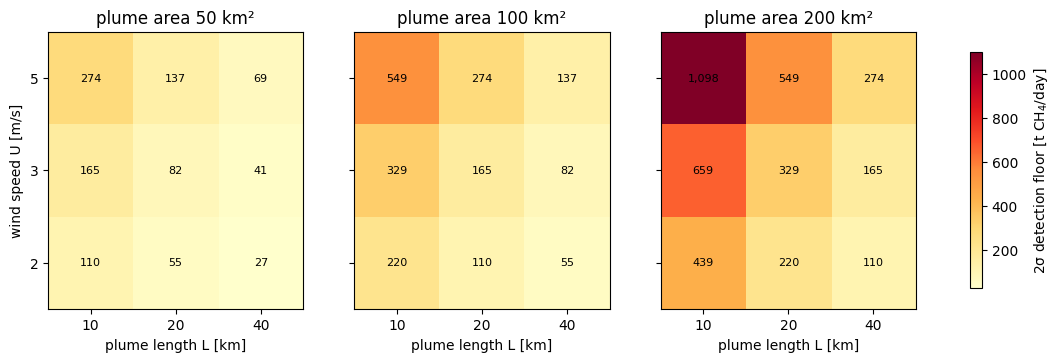

In [10]:
# @title Block 6B · Detection floor across 27 plume geometries
import itertools

NA_, P0_, g0_, Mair_ = 6.022e23, 101325., 9.807, 28.96e-3
NAIR_ = P0_/(g0_*Mair_)*NA_
SIG_  = 0.006*1850                          # ~11 ppb single-sounding precision
Q_CH4 = B5.CH4_t.sum()*0.6/6                # acute-phase daily rate, t/day

L_SET = [10, 20, 40]        # along-wind plume length in view [km]
U_SET = [2, 3, 5]           # wind speed [m/s]
A_SET = [50, 100, 200]      # plume area [km2]

rows = []
for L, U, A in itertools.product(L_SET, U_SET, A_SET):
    tau  = L*1e3 / U                                  # s
    ppb_per_t = ((1.0/86400*tau)*1e6/16.04*NA_)/(A*1e6)/NAIR_*1e9
    rows.append({'L_km':L, 'U_ms':U, 'A_km2':A,
                 'tau_h': round(tau/3600, 2),
                 'ppb_per_t_day': ppb_per_t,
                 'dXCH4_ppb': Q_CH4*ppb_per_t,
                 'sigma': Q_CH4*ppb_per_t/SIG_,
                 'floor_t_day': 2*SIG_/ppb_per_t})
SW = pd.DataFrame(rows)
SW['site_below_x'] = SW.floor_t_day / Q_CH4

lo, med, hi = SW.floor_t_day.quantile([0.05, 0.50, 0.95])
print(f"Site emission rate            : {Q_CH4:8.2f} t CH4/day")
print(f"Detection floor, 27 scenarios : {SW.floor_t_day.min():,.0f} - {SW.floor_t_day.max():,.0f} t/day")
print(f"  5th / median / 95th         : {lo:,.0f} / {med:,.0f} / {hi:,.0f} t/day")
print(f"Site is below the floor by    : {SW.site_below_x.min():.0f}x - {SW.site_below_x.max():.0f}x")
print(f"Max significance in ANY scenario: {SW.sigma.max():.3f} sigma  "
      f"-> undetectable across the entire plausible parameter space")

rec('6B','Detection floor, median',  med, 't/day')
rec('6B','Detection floor, 5-95 pct', f'{lo:,.0f} - {hi:,.0f}', 't/day')
rec('6B','Max significance, any geometry', SW.sigma.max(), 'sigma')

# ---- heatmap: floor vs L and U, at each plume area --------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for ax, A in zip(axes, A_SET):
    P = SW[SW.A_km2 == A].pivot(index='U_ms', columns='L_km', values='floor_t_day')
    im = ax.imshow(P.values, cmap='YlOrRd', aspect='auto', origin='lower',
                   vmin=SW.floor_t_day.min(), vmax=SW.floor_t_day.max())
    ax.set_xticks(range(len(L_SET))); ax.set_xticklabels(L_SET)
    ax.set_yticks(range(len(U_SET))); ax.set_yticklabels(U_SET)
    ax.set_xlabel('plume length L [km]'); ax.set_title(f'plume area {A} km²')
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            ax.text(j, i, f'{P.values[i,j]:,.0f}', ha='center', va='center', fontsize=8)
axes[0].set_ylabel('wind speed U [m/s]')
fig.colorbar(im, ax=axes, shrink=.85, label='2σ detection floor [t CH$_4$/day]')
plt.savefig(f'{PROJ}/figures/block6B_floor_sweep.png', dpi=300, bbox_inches='tight'); plt.show()
SW.to_csv(f'{PROJ}/data/outputs/block6B_geometry_sweep.csv', index=False)

---
## Block 7A · Eleven summers of Sentinel-2 — is the forest coming back?
**Why.** A single post-fire image tells you damage; a time series tells you recovery. We extract one peak-season NBR value per year for each severity class, and for an **unburnt control forest** that should stay flat. If the control drifts, the "recovery" is climate or sensor, not forest.

**Key formulas**
- peak-season composite, 15 Jun – 15 Sep, median of clear scenes (cloud < 30 %)
- `recovered % = NBR(year) / NBR(pre-fire baseline) × 100`, per severity class
- control drift = last year vs baseline; control σ = its year-to-year standard deviation — the natural "wobble" of a healthy forest

**Terms** &nbsp; the fire year itself is a **mixed** composite (its summer window spans the fire) and is excluded from both baseline and fit.

**Change for your fire** &nbsp; `LAST_YEAR`, `CTRL_BBOX`.

**Arischia result** &nbsp; recovered by 2026: Low **66.7 %** · Moderate **59.4 %** · High **51.9 %** · Very high **35.8 %** · control drift −1.4 %, control σ 0.0108 NBR — the climate signal is small

In [11]:
# @title Block 7A · Peak-season NBR per severity class vs an unburnt control
def peak_nbr(year, mask, geom):
    c = (S2C.filterBounds(geom).filterDate(f'{year}-06-15', f'{year}-09-15')
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE',30))
           .map(lambda i: i.updateMask(i.select('SCL').remap([3,8,9,10,11],[0]*5,1))))
    try:    return round(zs(c.median().normalizedDifference(['B8','B12']), mask, geom, ee.Reducer.mean(), 20), 4)
    except: return np.nan

rows = []
for y in range(FIRE_YEAR - 4, LAST_YEAR + 1):
    r = {'year': y}
    for k, v in CLASSES.items(): r[v] = peak_nbr(y, SEV.eq(k).selfMask(), EMS_G)
    r['Control'] = peak_nbr(y, FUEL, CONTROL)
    rows.append(r); print(' ', y, 'done')

B7 = pd.DataFrame(rows); display(B7)

# --- baseline check: which pre-fire years actually had a clear scene ---------
_valid = int(B7[B7.year < FIRE_YEAR][CLASSES[1]].notna().sum())
print(f"\nBaseline years actually used: "
      f"{sorted(B7[(B7.year<FIRE_YEAR) & B7[CLASSES[1]].notna()].year.tolist())}  (n={_valid})")
print(f"NOTE: {FIRE_YEAR} is a MIXED composite — the 15 Jun–15 Sep window spans the {FIRE_START} fire.")
print("      It is excluded from both the baseline and the recovery fit; it is shown for context only.")
rec(7,'Baseline years used', _valid, 'years')
rec(7,f'Control interannual sd {FIRE_YEAR-2}-{LAST_YEAR}', float(B7[B7.year>=FIRE_YEAR-2].Control.std()), 'NBR')


B7.to_csv(f'{PROJ}/data/outputs/recovery_nbr.csv', index=False)

base = B7[B7.year < FIRE_YEAR][list(CLASSES.values())].mean()
now  = B7[B7.year == LAST_YEAR][list(CLASSES.values())].iloc[0]
for c in CLASSES.values(): rec(7, f'{c}: recovered by {LAST_YEAR}', 100*now[c]/base[c], '%')
rec(7,f'Control drift {FIRE_YEAR-4}-{LAST_YEAR}',
    100*(B7[B7.year==LAST_YEAR].Control.iloc[0]/B7[B7.year<FIRE_YEAR].Control.mean()-1),'%')

  2016 done
  2017 done
  2018 done
  2019 done
  2020 done
  2021 done
  2022 done
  2023 done
  2024 done
  2025 done
  2026 done


,year,Low,Moderate,High,Very high,Control
0,2016,0.5790,0.5727,0.5441,0.5901,0.6157
1,2017,NaN,NaN,NaN,NaN,NaN
2,2018,0.5671,0.5636,0.5424,0.5835,0.6027
3,2019,0.5727,0.5676,0.5459,0.5879,0.6330
4,2020,0.4658,0.4262,0.3333,0.2024,0.6162
5,2021,0.2849,0.1820,0.0764,-0.1049,0.6185
6,2022,0.2908,0.2181,0.1578,0.0505,0.6158
7,2023,0.3201,0.2679,0.2229,0.1503,0.6127
8,2024,0.3341,0.2956,0.2473,0.1755,0.6097
9,2025,0.3766,0.3388,0.2892,0.2195,0.6351



Baseline years actually used: [2016, 2018, 2019]  (n=3)
NOTE: 2020 is a MIXED composite — the 15 Jun–15 Sep window spans the 2020-07-30 fire.
      It is excluded from both the baseline and the recovery fit; it is shown for context only.
  [7] Baseline years used                         3.00  years
  [7] Control interannual sd 2018-2026            0.01  NBR
  [7] Low: recovered by 2026                     66.74  %
  [7] Moderate: recovered by 2026                59.37  %
  [7] High: recovered by 2026                    51.88  %
  [7] Very high: recovered by 2026               35.76  %
  [7] Control drift 2016-2026                    -1.40  %


---
## Block 7B · Recovery model — when will the canopy, and the methane sink, return?
**Why.** Turn eleven observed years into a forecast. And be explicit about what is measured (canopy reflectance) versus modelled (soil methane uptake).

**Key formulas**
- `NBR(t) = NBR_base − A · e^(−t/k)` — exponential recovery toward the pre-fire baseline, time constant *k*
- equivalently `ln(NBR_base − NBR) = ln A − t/k` is a straight line → fitted with `np.polyfit`
- **90 % canopy** when the remaining deficit = 10 % of baseline · **full canopy** when the deficit < control σ
- **methane-sink window** = canopy years × a soil-microbial lag of **1.3–2.0** — an assumption, stated openly and tagged **[MODELLED]**

**Terms** &nbsp; **methanotrophs** live in the soil organic horizon; no optical, thermal or radar band reaches them, so their recovery can only be modelled from the canopy plus a lag.

**Outputs** &nbsp; `figures/block7D_recovery.png`, `figures/recovery_dashboard.html`, `data/outputs/block7D_*.csv`

**Arischia result**

| Severity | 2026 | k [yr] | 90 % canopy | full canopy | CH₄ sink (modelled) |
|---|:--:|:--:|:--:|:--:|:--:|
| Low | 66.7 % | 10.9 | 2039 | 2057 | 2045 – 2094 |
| Moderate | 59.4 % | 8.9 | 2038 | 2053 | 2043 – 2085 |
| High | 51.9 % | 8.3 | 2038 | 2052 | 2044 – 2083 |
| Very high | 35.8 % | 8.3 | 2041 | 2055 | 2047 – 2089 |

Severity sets *how deep the hole is*, not how fast the forest climbs out.

,year,Low %,Moderate %,High %,Very high %
0,2021,49.7,32.0,14.0,-17.9
1,2022,50.8,38.4,29.0,8.6
2,2023,55.9,47.2,41.0,25.6
3,2024,58.3,52.0,45.4,29.9
4,2025,65.7,59.7,53.1,37.4
5,2026,66.7,59.4,51.9,35.8


,year,Low Δ%/yr,Moderate Δ%/yr,High Δ%/yr,Very high Δ%/yr
0,2021,NaN,NaN,NaN,NaN
1,2022,1.1,6.4,15.0,26.5
2,2023,5.1,8.8,12.0,17.0
3,2024,2.4,4.8,4.4,4.3
4,2025,7.4,7.7,7.7,7.5
5,2026,1.0,-0.3,-1.2,-1.6


,class,rec_2026_%,mean_rate_%yr,k_yr,canopy_90%,canopy_full,sink_lo,sink_hi
0,Low,66.7,3.40,10.9,2039,2057,2045,2094
1,Moderate,59.4,5.48,8.9,2038,2053,2043,2085
2,High,51.9,7.58,8.3,2038,2052,2044,2083
3,Very high,35.8,10.74,8.3,2041,2055,2047,2089


  [7D] [MODELLED] Low: methane-sink normalisation     2045-2094  yr
  [7D] [MODELLED] Moderate: methane-sink normalisation     2043-2085  yr
  [7D] [MODELLED] High: methane-sink normalisation     2044-2083  yr
  [7D] [MODELLED] Very high: methane-sink normalisation     2047-2089  yr


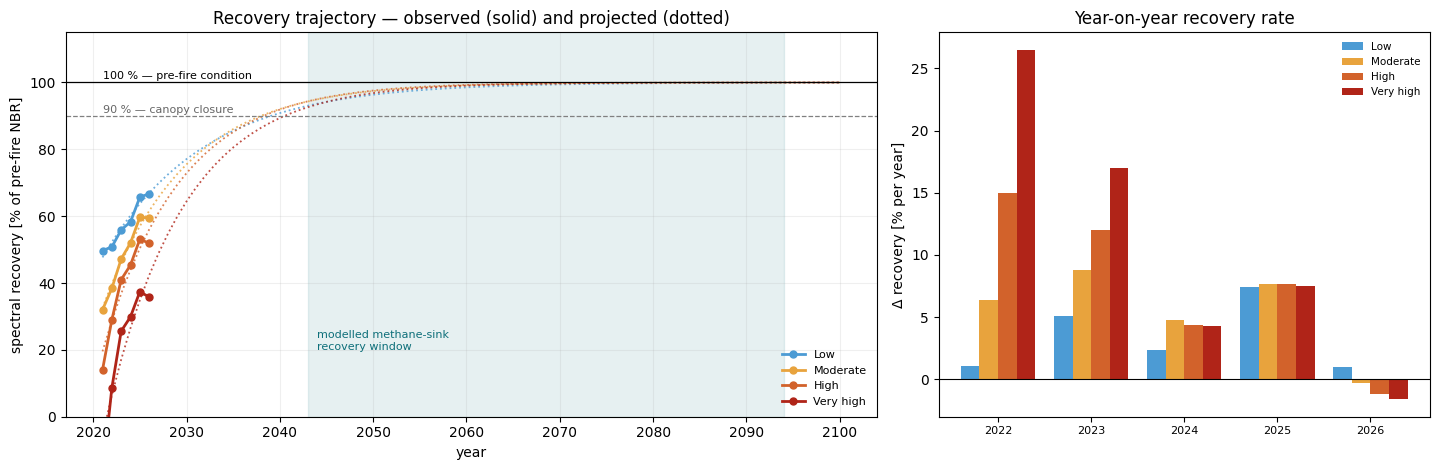

saved -> figures/recovery_dashboard.html


In [12]:
# @title Block 7B · Recovery model — canopy and methane-sink timelines {"vertical-output":true}
import base64, io

CL      = list(CLASSES.values())
CTRL_SD = float(B7[B7.year >= FIRE_YEAR - 2].Control.std())
BASE    = {c: B7[B7.year < FIRE_YEAR][c].mean() for c in CL}
BASE_YRS = B7[(B7.year < FIRE_YEAR) & B7[CL[0]].notna()].year.tolist()
MISS_YRS = B7[(B7.year < FIRE_YEAR) & B7[CL[0]].isna()].year.tolist()

# ---- annual recovery % and year-on-year rate --------------------------------
TR = pd.DataFrame({'year': B7[B7.year > FIRE_YEAR].year.values})
for c in CL:
    TR[c] = (100*B7[B7.year > FIRE_YEAR][c].values / BASE[c]).round(1)
RATE = TR.copy()
for c in CL: RATE[c] = TR[c].diff().round(1)
display(TR.rename(columns={c: f'{c} %' for c in CL}))
display(RATE.rename(columns={c: f'{c} Δ%/yr' for c in CL}))

# ---- exponential projection + three normalisation criteria ------------------
LAG_LO, LAG_HI = 1.3, 2.0          # ASSUMPTION: soil methanotroph recovery lags canopy
SUM7D, PROJ_CURVES = [], {}
for c in CL:
    post = B7[B7.year > FIRE_YEAR][['year', c]].copy()
    post['t'] = post.year - FIRE_YEAR
    post['def'] = BASE[c] - post[c]
    A = np.polyfit(post.t, np.log(post['def']), 1)          # log-deficit is linear
    k = -1/A[0]
    yr = lambda tgt: FIRE_YEAR + (np.log(tgt) - A[1])/A[0]
    y90, yfull = yr(0.10*BASE[c]), yr(CTRL_SD)
    t90 = y90 - FIRE_YEAR
    SUM7D.append({'class': c,
                  'rec_2026_%': TR[c].iloc[-1],
                  'mean_rate_%yr': round((TR[c].iloc[-1]-TR[c].iloc[0])/(len(TR)-1), 2),
                  'k_yr': round(k, 1),
                  'canopy_90%': int(round(y90)), 'canopy_full': int(round(yfull)),
                  'sink_lo': int(round(FIRE_YEAR + t90*LAG_LO)),
                  'sink_hi': int(round(FIRE_YEAR + (yfull-FIRE_YEAR)*LAG_HI))})
    tp = np.arange(1, 81)
    PROJ_CURVES[c] = (FIRE_YEAR+tp, 100*(BASE[c]-np.exp(A[1]+A[0]*tp))/BASE[c])

S7D = pd.DataFrame(SUM7D); display(S7D)
S7D.to_csv(f'{PROJ}/data/outputs/block7D_normalisation_range.csv', index=False)
TR.to_csv(f'{PROJ}/data/outputs/block7D_trajectory.csv', index=False)
for _, r in S7D.iterrows():
    rec_model('7D', f"{r['class']}: methane-sink normalisation",
              f"{r.sink_lo}-{r.sink_hi}", 'yr')

# ---- figure -----------------------------------------------------------------
COL = {'Low':'#4C9BD4','Moderate':'#E8A33D','High':'#D2622B','Very high':'#B02418'}
fig, ax = plt.subplots(1, 2, figsize=(14.5, 4.8),
                       gridspec_kw={'width_ratios':[1.65, 1]})
for c in CL:
    ax[0].plot(TR.year, TR[c], 'o-', color=COL[c], lw=2, ms=5, label=c, zorder=5)
    yy, vv = PROJ_CURVES[c]; ax[0].plot(yy, vv, ':', color=COL[c], lw=1.3, alpha=.8)
ax[0].axhline(100, color='k', lw=.9); ax[0].axhline(90, color='0.5', ls='--', lw=.9)
ax[0].text(FIRE_YEAR+1, 91, '90 % — canopy closure', fontsize=8, color='0.4')
ax[0].text(FIRE_YEAR+1, 101, '100 % — pre-fire condition', fontsize=8)
ax[0].axvspan(S7D['sink_lo'].min(), S7D['sink_hi'].max(), color='#0E6F7A', alpha=.10)
ax[0].text(S7D['sink_lo'].min()+1, 20, 'modelled methane-sink\nrecovery window',
           fontsize=8, color='#0E6F7A')
ax[0].set_xlabel('year'); ax[0].set_ylabel('spectral recovery [% of pre-fire NBR]')
ax[0].set_title('Recovery trajectory — observed (solid) and projected (dotted)')
ax[0].legend(fontsize=8, frameon=False); ax[0].set_ylim(0, 115); ax[0].grid(alpha=.2)

w, x = 0.2, np.arange(len(RATE)-1)
for i, c in enumerate(CL):
    ax[1].bar(x + i*w, RATE[c].values[1:], w, color=COL[c], label=c)
ax[1].set_xticks(x + 1.5*w); ax[1].set_xticklabels(RATE.year.values[1:], fontsize=8)
ax[1].axhline(0, color='k', lw=.8)
ax[1].set_ylabel('Δ recovery [% per year]'); ax[1].set_title('Year-on-year recovery rate')
ax[1].legend(fontsize=7.5, frameon=False)
plt.tight_layout(); plt.savefig(f'{PROJ}/figures/block7D_recovery.png', dpi=300)
buf = io.BytesIO(); plt.savefig(buf, format='png', dpi=140, bbox_inches='tight')
IMG = base64.b64encode(buf.getvalue()).decode(); plt.show()

# ---- HTML dashboard ---------------------------------------------------------
gedi_note = ("GEDI structural check did not pass its validity gate — the unburnt control "
             "returned a spurious deficit, so canopy-height recovery is reported as "
             "attempted-and-insufficient and is <b>not</b> used in this projection."
             if 'VALID' in dir() and not VALID else
             "GEDI structural recovery passed its control gate and is shown for comparison.")

rows_tr = "".join(f"<tr><td>{int(r.year)}</td>" +
    "".join(f"<td class='n'>{r[c]:.1f}</td><td class='n d'>{'' if pd.isna(RATE[c].iloc[i]) else f'{RATE[c].iloc[i]:+.1f}'}</td>"
            for c in CL) + "</tr>" for i, r in TR.iterrows())
rows_sum = "".join(
    f"<tr><th>{r['class']}</th><td class='n'>{r['rec_2026_%']:.1f} %</td>"
    f"<td class='n'>{r['mean_rate_%yr']:.2f}</td><td class='n'>{r['k_yr']:.1f}</td>"
    f"<td class='n'>{r['canopy_90%']}</td><td class='n'>{r['canopy_full']}</td>"
    f"<td class='n hi'>{r['sink_lo']} – {r['sink_hi']}</td></tr>" for _, r in S7D.iterrows())

open(f'{PROJ}/figures/recovery_dashboard.html','w').write(f"""<!doctype html><meta charset=utf-8>
<title>Recovery Trajectory — Arischia</title>
<style>
 body{{margin:0;background:#FBFBF9;color:#15181A;font:16px/1.6 Georgia,serif;padding:34px 30px 70px}}
 .w{{max-width:1120px;margin:0 auto}}
 h1{{font-size:27px;margin:0 0 6px;letter-spacing:-.01em}}
 .sub{{font-style:italic;color:#3C4247;margin:0 0 24px}}
 h2{{font-size:17px;margin:32px 0 10px;border-top:1.5px solid #15181A;padding-top:12px}}
 img{{width:100%;border:1px solid #D6D9D2;border-radius:3px;background:#fff}}
 table{{border-collapse:collapse;width:100%;font-size:13.5px;margin:12px 0;background:#fff;
        border:1px solid #D6D9D2}}
 th,td{{padding:8px 11px;border-bottom:1px solid #E6E8E3;text-align:left}}
 thead th{{background:#F2F3F1;font:600 10.5px/1.4 ui-monospace,monospace;letter-spacing:.09em;
           text-transform:uppercase;color:#6B7178}}
 td.n{{text-align:right;font-family:ui-monospace,monospace;font-variant-numeric:tabular-nums}}
 td.d{{color:#8a8f94;font-size:12px}}
 td.hi{{background:#E5EFF0;font-weight:700;color:#0A5C68}}
 .box{{border:1px solid #D6D9D2;border-left:3px solid #A8380C;background:#fff;padding:15px 19px;margin:18px 0}}
 .box.t{{border-left-color:#0A5C68}}
 .lb{{font:600 9.5px/1 ui-monospace,monospace;letter-spacing:.15em;text-transform:uppercase;
      color:#A8380C;display:block;margin-bottom:8px}}
 .box.t .lb{{color:#0A5C68}} .box p{{margin:0 0 .7em;font-size:15.5px}} .box p:last-child{{margin:0}}
</style>
<div class=w>
<h1>Recovery Trajectory and Methane-Sink Normalisation</h1>
<p class=sub>{SITE_LABEL} · {FIRE_START} to {FIRE_END} · {B3.ha.sum():.0f} ha ·
{len(B7)} years of Sentinel-2, stratified by burn severity</p>

<img src="data:image/png;base64,{IMG}">

<h2>Normalisation range by severity class</h2>
<table><thead><tr><th>Severity</th><th>Recovered 2026</th><th>Mean rate %/yr</th>
<th>Time constant k</th><th>Canopy 90 %</th><th>Canopy full</th>
<th>Methane sink (modelled)</th></tr></thead><tbody>{rows_sum}</tbody></table>

<div class="box t"><span class=lb>Why the sink column is a range, not a year</span>
<p>The canopy columns are <b>measured</b>: they are an exponential projection of {len(B7)} years of
observed Sentinel-2 NBR, with an unburnt control forest confirming that no more than ~1 % of the
signal comes from climate or sensor drift.</p>
<p>The methane-sink column is <b>modelled</b>. Recovering the spectral signature of a forest is not
the same as recovering its function. The soil methanotrophic community that oxidises atmospheric
methane depends on the organic horizon, soil structure, moisture regime and microbial inoculum —
none of which are observable from orbit. Published work consistently finds soil microbial recovery
lagging canopy recovery, so this projection applies a lag factor of
<b>{LAG_LO}× to {LAG_HI}×</b> to the canopy timeline. That factor is an assumption, stated openly,
and it is the single largest uncertainty in this projection.</p>
<p><b>Closing the range would require ground measurement</b> — soil flux chambers or an
eddy-covariance tower on a severity gradient. That is identified as the primary further-research
direction of this project and is explicitly outside its scope.</p></div>

<div class=box><span class=lb>Caveats a reader must have</span>
<p><b>{FIRE_YEAR} is excluded.</b> The peak-season window (15 Jun – 15 Sep) spans the {FIRE_START} fire, so the
{FIRE_YEAR} composite mixes pre- and post-fire imagery. It is used in neither the baseline nor the fit.</p>
<p><b>The baseline rests on {len(BASE_YRS)} annual composites</b> ({', '.join(map(str, MISS_YRS)) or 'no year'} returned no usable cloud-free peak-season
scene), so its dispersion is weakly constrained. The "full recovery" threshold therefore uses the
<b>control forest's interannual standard deviation ({CTRL_SD:.4f} NBR)</b> — the measured natural
year-to-year wobble of a healthy forest — rather than the burn-class baseline scatter.</p>
<p><b>{gedi_note}</b></p></div>

<h2>Year-by-year trajectory and rate</h2>
<table><thead><tr><th>Year</th>{''.join(f'<th colspan=2>{c}</th>' for c in CL)}</tr>
<tr><th></th>{''.join('<th>% rec</th><th>Δ/yr</th>' for _ in CL)}</tr></thead>
<tbody>{rows_tr}</tbody></table>
<p style="font-size:13px;color:#6B7178">Recovery is expressed as a percentage of the {FIRE_YEAR-4}–{FIRE_YEAR-1}
pre-fire mean NBR for that severity class. Δ/yr is the year-on-year change in that percentage.</p>
</div>""")
print('saved -> figures/recovery_dashboard.html')

---
## Block 8 · Results register and quick-look map
**Why.** One place where every number is visible, exported and traceable to the block that produced it.

**Outputs** &nbsp; side-by-side map (pre-fire vs post-fire layers) saved as `figures/dashboard.html` · results register → `data/outputs/session1_results.csv` · summary figure → `figures/session1_summary.png`

> Interactive maps are removed from the saved notebook (GitHub cannot load Earth Engine tiles, and they add megabytes). Run the block in Colab to see them live.

,block,result,value,unit
0,1,Reference perimeter,638.990253,ha
1,1,Fuel area (10 m mask),458.0,ha
2,1,Mean slope,23.063579,deg
3,2,Mean AGB density,117.345599,t/ha
4,2,Standing biomass,53694.0,t
5,2,July NDMI baseline 2016-2019,0.301567,
6,2,July 2020 NDMI anomaly,-0.0092,
7,2,Anomaly in baseline sigma,-0.66,sigma
8,2,Mean 2m T Jun-Jul,18.070451,degC
9,2,Precip Jun-Jul,180.626308,mm


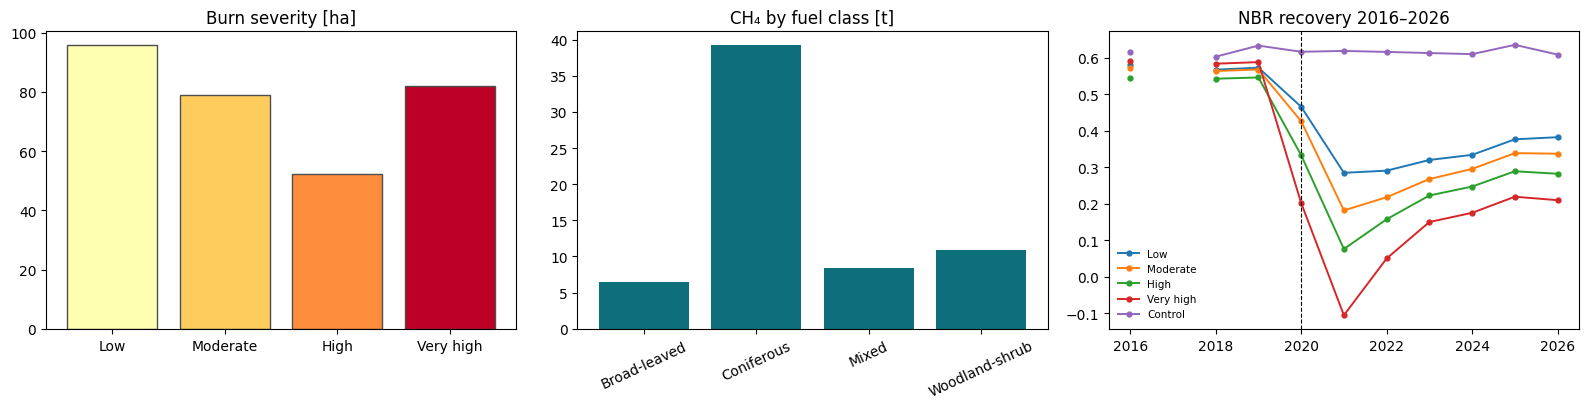

In [13]:
# @title Block 8 · Side-by-side map, results register and summary figure {"vertical-output":true}
from folium.plugins import DualMap
V = {'rgb':{'bands':['B4','B3','B2'],'min':200,'max':2500},
     'fc' :{'bands':['B12','B8','B4'],'min':300,'max':3500},
     'sev':{'min':1,'max':4,'palette':['#ffffb2','#fecc5c','#fd8d3c','#bd0026']},
     'agb':{'min':0,'max':200,'palette':['#f7fcf5','#74c476','#00441b']},
     'nbr':{'min':0,'max':1.0,'palette':['#f7f7f7','#fdae61','#b2182b']}}

CENTER = AOI.centroid(10).coordinates().getInfo()[::-1]     # [lat, lon] of the study box
m = DualMap(location=CENTER, zoom_start=13, tiles=None)
for s in (m.m1, m.m2):
    folium.TileLayer('https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
                     attr='Google', name='Satellite', max_zoom=20).add_to(s)
ee_tile(PRE_I, V['rgb'], '1 · Pre-fire true colour', True).add_to(m.m1)
ee_tile(AGB.updateMask(FUEL), V['agb'], '2 · Biomass AGB t/ha').add_to(m.m1)
ee_tile(FUEL, {'palette':'#1b7837'}, '3 · Fuel mask 10 m').add_to(m.m1)
ee_tile(POST_I, V['fc'], '4 · Post-fire false colour', True).add_to(m.m2)
ee_tile(SEV, V['sev'], '5 · Burn severity').add_to(m.m2)
ee_tile(dNBR.updateMask(BURN), V['nbr'], '6 · dNBR').add_to(m.m2)
for s in (m.m1, m.m2):
    folium.GeoJson(gdf.__geo_interface__, name='7 · Reference perimeter',
        style_function=lambda x: {'color':'white','weight':2,'fillOpacity':0}).add_to(s)
    folium.LayerControl(collapsed=False).add_to(s)
m.save(f'{PROJ}/figures/dashboard.html'); display(m)

def _bkey(b):
    """Sort 1,2,...,5,5B,6,6B,7,7B,7C,8,9 in natural order regardless of type."""
    b = str(b)
    num = ''.join(ch for ch in b if ch.isdigit())
    suf = ''.join(ch for ch in b if ch.isalpha()).upper()
    return (int(num) if num else 99, suf)

SUM = pd.DataFrame([{'block': str(v['block']), 'result': k,
                     'value': v['value'], 'unit': v['unit']}
                    for k, v in R.items()])
SUM = (SUM.assign(_k=SUM.block.map(_bkey))
          .sort_values('_k').drop(columns='_k').reset_index(drop=True))
display(SUM); SUM.to_csv(f'{PROJ}/data/outputs/session1_results.csv', index=False)

fig, ax = plt.subplots(1, 3, figsize=(16,4.2))
ax[0].bar(B3.severity, B3.ha, color=['#ffffb2','#fecc5c','#fd8d3c','#bd0026'], edgecolor='0.3')
ax[0].set_title('Burn severity [ha]')
ax[1].bar(B5['class'], B5.CH4_t, color='#0E6F7A'); ax[1].set_title('CH₄ by fuel class [t]')
ax[1].tick_params(axis='x', rotation=25)
for c in list(CLASSES.values())+['Control']:
    ax[2].plot(B7.year, B7[c], marker='o', ms=3.5, lw=1.4, label=c)
ax[2].axvline(2020, color='k', ls='--', lw=.8); ax[2].set_title('NBR recovery 2016–2026')
ax[2].legend(fontsize=7.5, frameon=False)
plt.tight_layout(); plt.savefig(f'{PROJ}/figures/session1_summary.png', dpi=300); plt.show()

---
## Block 8B · The seven-layer dashboard
**Why.** A single, shareable HTML file a journalist or analyst can open in any browser — no Python, no account.

| Layer | What it shows |
|---|---|
| ① Pre-fire true colour | Sentinel-2 B4 / B3 / B2 — the forest as your eye would see it |
| ② Post-fire false colour | B12 / B8 / B4 — char is bright in SWIR, so the scar stands out before any index is computed |
| ③ Pre-fire biomass | ESA CCI AGB inside the fuel mask, t ha⁻¹ |
| ④ Burn severity | the four dNBR classes from Block 3 |
| ⑤ CH₄ released | t ha⁻¹ per severity class, from Block 5B |
| ⑥ Recovered by the last year | % of pre-fire NBR, from Block 7B |
| ⑦ EMS perimeter | the independent reference outline |

The findings panel is computed from the register — change the site and it rewrites itself. Output: `figures/dashboard_novelty.html`.

<img src="https://raw.githubusercontent.com/2248220hub/OpenCarbon-Forest-FireDebt-EO-Toolkit/main/assets/results/dashboard_map.jpg" width="100%" alt="Arischia dashboard">

In [14]:
# @title Block 8B · Seven-layer interactive dashboard, saved as one HTML file {"vertical-output":true}
from folium.plugins import MiniMap, Fullscreen, MousePosition
import branca.colormap as cm

# ---- derived novelty layers -------------------------------------------------
ch4_ha  = {s: float(B5B[B5B.sev==s].CH4_t.sum() / max(B5B[B5B.sev==s].ha.sum(), 1e-9))
           for s in CLASSES}
REC26   = {k: float(TR[v].iloc[-1]) for k, v in CLASSES.items()}   # % recovered in LAST_YEAR (Block 7B)

CH4_MAP = ee.Image(0)
REC_MAP = ee.Image(0)
for s in CLASSES:
    CH4_MAP = CH4_MAP.where(SEV.eq(s), ch4_ha[s])
    REC_MAP = REC_MAP.where(SEV.eq(s), REC26[s])
CH4_MAP = CH4_MAP.updateMask(BURN).rename('ch4_t_ha')
REC_MAP = REC_MAP.updateMask(BURN).rename('recovered_pct')

V = {'rgb':{'bands':['B4','B3','B2'],'min':200,'max':2500},
     'fc' :{'bands':['B12','B8','B4'],'min':300,'max':3500},
     'sev':{'min':1,'max':4,'palette':['#ffffb2','#fecc5c','#fd8d3c','#bd0026']},
     'agb':{'min':0,'max':200,'palette':['#f7fcf5','#a1d99b','#31a354','#00441b']},
     'ch4':{'min':0,'max':max(ch4_ha.values())*1.05,'palette':['#f7f4f9','#c994c7','#dd1c77','#67001f']},
     'rec':{'min':30,'max':75,'palette':['#b2182b','#f4a582','#92c5de','#2166ac']}}

CENTER = AOI.centroid(10).coordinates().getInfo()[::-1]
m = folium.Map(location=CENTER, zoom_start=13, tiles=None, control_scale=True)
folium.TileLayer('https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
                 attr='Google', name='Satellite', max_zoom=20).add_to(m)
folium.TileLayer('OpenStreetMap', name='Light basemap').add_to(m)

def lyr(img, vis, name, show=False, opacity=1.0):
    t = folium.raster_layers.TileLayer(
        tiles=ee.Image(img).getMapId(vis)['tile_fetcher'].url_format, attr='GEE',
        name=name, overlay=True, control=True, show=show, opacity=opacity, max_zoom=20)
    t.add_to(m); return t

t_pre = lyr(PRE_I,  V['rgb'], '① Pre-fire true colour · 29 Jul 2020', True)
t_post= lyr(POST_I, V['fc'],  '② Post-fire false colour · 13 Aug 2020', False)
t_agb = lyr(AGB.updateMask(FUEL), V['agb'], '③ Pre-fire biomass [t/ha]', False, 0.75)
t_sev = lyr(SEV,     V['sev'], '④ Burn severity (dNBR)',      True, 0.80)
t_ch4 = lyr(CH4_MAP, V['ch4'], '⑤ CH₄ released [t/ha]',       False, 0.85)
t_rec = lyr(REC_MAP, V['rec'], '⑥ Recovered by 2026 [%]',     False, 0.85)

folium.GeoJson(gdf.__geo_interface__, name='⑦ CEMS EMSR449 reference perimeter',
               style_function=lambda x: {'color':'#ffffff','weight':2.5,'fillOpacity':0}).add_to(m)

cm.LinearColormap(V['agb']['palette'], vmin=0, vmax=200,
                  caption='Above-ground biomass [t/ha]').add_to(m)
cm.LinearColormap(V['rec']['palette'], vmin=30, vmax=75,
                  caption='Spectral recovery by 2026 [%]').add_to(m)

MiniMap(toggle_display=True, position='bottomleft').add_to(m)
Fullscreen().add_to(m); MousePosition().add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

# ---- opacity sliders + severity legend + findings panel --------------------
# ---- title + findings + combined legend/opacity panel ----------------------
# ---- every number on the panel is computed from the register ---------------
GWP100    = 27.2                                   # IPCC AR6, as in Block 5A
FIRE_DAYS = (pd.Timestamp(FIRE_END) - pd.Timestamp(FIRE_START)).days
S5P_DAYS  = int(S5P_END.difference(S5P_START, 'day').getInfo())
C_EMIT    = (B5.CO2_t.sum()*12/44 + B5.CO_t.sum()*12/28 + B5.CH4_t.sum()*12/16
             + B5.PM25_t.sum()*0.60)               # 0.60 = assumed carbon fraction of PM2.5
C_FUEL    = B5.BB_t.sum()*0.47                     # 0.47 = IPCC carbon fraction of dry biomass
CLOSURE   = 100*C_EMIT/C_FUEL
DUTY      = 100*B5.BB_t.sum()/BB_UPPER
DEBT      = (B5.CH4_t.sum()/(B5.burn_ha.sum()*SINK[1]/1000),
             B5.CH4_t.sum()/(B5.burn_ha.sum()*SINK[0]/1000))
PRECIP    = R['Precip Jun-Jul']['value']; TMEAN = R['Mean 2m T Jun-Jul']['value']
DRY       = abs(s20) >= 1

TITLE    = DASHBOARD_TITLE
SUBTITLE = (f"{SITE_LABEL} &middot; {FIRE_START} to {FIRE_END}"
            f"<br>{B3.ha.sum():.0f} ha burned &middot; {B5.CH4_t.sum():.1f} t CH<sub>4</sub> &middot; "
            f"{B5.CO2_t.sum() + B5.CH4_t.sum()*GWP100:,.0f} t CO<sub>2</sub>e")
AUTHOR   = AUTHOR_LINE

FINDINGS = [
 ("Zero CH₄ retrievals" if len(B6['CH4']) == 0 else "CH₄ retrievals",
  f"{len(B6['CH4'])} of {S5P_DAYS} days valid; CO returned {len(B6['CO'])}. Predicted {dCH4/SIG:.3f} σ before looking."),
 ("Detection floor",
  f"{SW.floor_t_day.min():,.0f}–{SW.floor_t_day.max():,.0f} t CH₄/day across {len(SW)} geometries. Max achievable σ = {SW.sigma.max():.2f}."),
 ("Diurnal duty cycle",
  f"{DUTY:.1f} % — about {24*DUTY/100:.1f} equivalent full-power hours per day."),
 ("Methane debt",
  f"{DEBT[0]:.0f}–{DEBT[1]:.0f} years of the forest's own uptake, released in {FIRE_DAYS} days."),
 ("Carbon closure",
  f"{CLOSURE:.1f} % — emission factors and carbon fraction are consistent."),
 ("Drought-primed fire" if DRY else "Not a drought fire",
  f"NDMI {s20:+.2f} σ · {PRECIP:.1f} mm rain · {TMEAN:.1f} °C before ignition. "
  + ("Fuel was anomalously dry." if DRY else "Ignition-limited, not fuel-limited.")),
]

sliders = "".join(
    f"<div class='row'><span>{lbl}</span>"
    f"<input type='range' min='0' max='100' value='{int(op*100)}' "
    f"oninput=\"{t.get_name()}.setOpacity(this.value/100)\"></div>"
    for lbl, t, op in [('Biomass', t_agb, .75), ('Severity', t_sev, .80),
                       ('CH₄/ha',  t_ch4, .85), ('Recovery', t_rec, .85),
                       ('Post-fire', t_post, 1.0)])

sev_chips = "".join(
    f"<div class='chip'><i style='background:{c}'></i><span>{n}</span><b>{h:.1f} ha</b></div>"
    for n, c, h in zip(CLASSES.values(), V['sev']['palette'], B3.ha.tolist()))

find_html = "".join(f"<div class='f'><b>{i+1}. {t}</b><span>{d}</span></div>"
                    for i, (t, d) in enumerate(FINDINGS))

m.get_root().html.add_child(folium.Element(f"""
<style>
 /* push Leaflet's top-right controls clear of the colour bars */
 .leaflet-top.leaflet-right {{ margin-top: 62px; }}

 .pnl{{position:fixed;z-index:9999;background:rgba(255,255,255,.96);border:1px solid #c9cdc8;
       border-radius:5px;padding:11px 13px;font:12px/1.45 system-ui,-apple-system,sans-serif;
       box-shadow:0 2px 12px rgba(0,0,0,.20)}}
 .pnl h4{{margin:0 0 8px;font-size:10px;letter-spacing:.13em;text-transform:uppercase;color:#6b7178}}

 /* TITLE — top left */
 #title{{top:10px;left:12px;width:288px;border-left:4px solid #A8380C}}
 #title .t{{font:600 14.5px/1.28 Georgia,serif;color:#15181A;margin-bottom:6px}}
 #title .s{{font-size:11.5px;color:#3C4247;line-height:1.5}}
 #title .a{{font-size:10px;color:#8a8f94;margin-top:7px;border-top:1px solid #eee;padding-top:6px}}

 /* FINDINGS — below the title */
 #find{{top:150px;left:12px;width:288px;max-height:58vh;overflow-y:auto}}
 .f{{border-bottom:1px solid #eee;padding:7px 0}} .f:last-child{{border:0}}
 .f b{{display:block;color:#A8380C;font-size:11.5px;margin-bottom:2px}}
 .f span{{font-size:11px;color:#444}}

 /* LEGEND + OPACITY — merged, bottom right, no longer clashing with LayerControl */
 #ctrl{{bottom:26px;right:12px;width:252px}}
 #ctrl .sep{{border-top:1px solid #e2e5e0;margin:11px 0 9px}}
 .chip{{display:flex;align-items:center;gap:8px;margin:4px 0;font-size:11.5px}}
 .chip i{{width:17px;height:11px;border:1px solid #9aa;display:inline-block;flex:none}}
 .chip span{{flex:1}} .chip b{{color:#555;font-weight:600;font-size:10.5px}}
 .row{{display:flex;align-items:center;gap:8px;margin:5px 0}}
 .row span{{width:62px;font-size:11px;color:#333}} .row input{{flex:1}}
</style>

<div class='pnl' id='title'>
  <div class='t'>{TITLE}</div>
  <div class='s'>{SUBTITLE}</div>
  <div class='a'>{AUTHOR}</div>
</div>

<div class='pnl' id='find'><h4>Six novelty findings</h4>{find_html}</div>

<div class='pnl' id='ctrl'>
  <h4>Burn severity</h4>{sev_chips}
  <div class='sep'></div>
  <h4>Layer opacity</h4>{sliders}
</div>
"""))

m.save(f'{PROJ}/figures/dashboard_novelty.html'); display(m)
print('saved -> figures/dashboard_novelty.html')

saved -> figures/dashboard_novelty.html


---
## Where to go next

- **Run it on your own fire** — edit Block 0, *Runtime → Run all*, compare your register with the Arischia values in each card.
- **Read the method in full** — [`docs/`](https://github.com/2248220hub/OpenCarbon-Forest-FireDebt-EO-Toolkit/tree/main/docs) has the setup guide, the adaptation guide, the methods note and the technical report.
- **Share the result** — the two HTML dashboards in your Drive `figures/` folder open in any browser.

### Credits
Developed by **Vinoth Emberumal** for the *Earth Observation* course of **Prof. Ferdinando Nunziata**, MSc Space & Astronautical Engineering, **Sapienza University of Rome**. The emission-factor table and the independent reference budget come from **G. Laneve & V. Pampanoni (2021)**, *Review of satellite based support to forest fire environmental impact assessment: the example of Arischia (Italy) forest fire*, Geografia, Riscos e Protecção Civil 2, 163–178, [doi:10.34037/978-989-9053-06-9_1.2_12](https://doi.org/10.34037/978-989-9053-06-9_1.2_12). Data: Copernicus (Sentinel-2, Sentinel-5P, CORINE, EMS), ESA (WorldCover, CCI Biomass), NASA (MODIS), ECMWF (ERA5-Land), processed in Google Earth Engine.

### Cite
Emberumal, V. (2026). *OpenCarbon · Forest Fire-Debt EO Toolkit*. https://github.com/2248220hub/OpenCarbon-Forest-FireDebt-EO-Toolkit — see `CITATION.cff`.

*Code MIT-licensed. Figures and documents CC BY 4.0.*